# Using Pandas for Data Analysis

- Importing files into a dataframe in pandas is very easy and straightforawrd
- It can take the following file types:
    - CSV/TXT
    - Excel
    - SAS
    - JSON
    - XML
    - SQL Data pull from a database
- To use a file with Jupyter notebooks:
    - If the file is saved in the same location, you don't need to specify the path/directory
    - Otherwise, you need to specify the directory with the file name

In [1]:
import pandas as pd
import numpy as np

`r'C:\Users\srika\OneDrive\Documents\AIML Course\Python Project'` for Windows example

In [4]:
# df = pd.read_csv('/Users/bassel_instructor/Documents/Datasets/school_grades.csv')
df = pd.read_csv('school_grades.csv')

In [5]:
df

,gender,class group,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68
...,...,...,...,...,...,...,...,...
995,male,group C,high school,standard,none,73,70,65
996,male,group D,associate's degree,free/reduced,completed,85,91,92
997,female,group C,some high school,free/reduced,none,32,35,41
998,female,group C,some college,standard,none,73,74,82


In [6]:
# get the top 8 rows
# no num specified -> 5 rows by default
df.head(8)

,gender,class group,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68
5,female,group D,high school,standard,none,63,77,76
6,female,group A,bachelor's degree,standard,none,62,59,63
7,male,group E,some college,standard,completed,93,88,84


In [7]:
# get the bottom 7 rows
df.tail(7)

,gender,class group,parental level of education,lunch,test preparation course,math score,reading score,writing score
993,female,group A,associate's degree,standard,none,58,54,58
994,male,group E,high school,free/reduced,completed,86,82,75
995,male,group C,high school,standard,none,73,70,65
996,male,group D,associate's degree,free/reduced,completed,85,91,92
997,female,group C,some high school,free/reduced,none,32,35,41
998,female,group C,some college,standard,none,73,74,82
999,male,group A,some college,standard,completed,65,60,62


In [8]:
# get a random sample of data
df.sample(12)

,gender,class group,parental level of education,lunch,test preparation course,math score,reading score,writing score
392,female,group C,some college,free/reduced,none,13,29,23
601,female,group D,high school,standard,none,69,71,76
362,female,group B,some high school,standard,completed,51,63,66
372,female,group C,bachelor's degree,free/reduced,completed,56,65,73
557,male,group C,some college,free/reduced,none,69,68,62
965,female,group E,bachelor's degree,standard,none,86,87,89
644,female,group C,some high school,standard,none,40,48,49
602,male,group C,high school,standard,none,43,50,45
877,male,group E,some college,free/reduced,completed,75,65,66
740,male,group B,some college,standard,none,52,53,51


In [9]:
df.shape

(1000, 8)

In [10]:
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} columns')

This dataset has 1000 rows and 8 columns


In [11]:
df.isna().sum()

gender                         0
class group                    0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

**Observations**
- The data has no null values
- We have multiple categorical columns (e.g. gender, class groups, lunch)
- There are different level of eductions for the student's parents
- We're seeing higher numbers of "some high school" and "some college". This is a sample. We need to confirm our observation of the true distribution using data analysis below.
- Lunch seems to have categories

In [12]:
df.isna().sum().sum()

np.int64(0)

`info()` provides null counts, data types, and data size all in one.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   class group                  1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [14]:
df.info(memory_usage='deep') # to ge the true mem consumption

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   class group                  1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 303.4 KB


In [15]:
# to improve memory consumption - chang the datatype to lower size
df[['math score','reading score','writing score']] = df[['math score','reading score','writing score']].apply(pd.to_numeric, downcast='integer')

In [16]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   class group                  1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int8  
 6   reading score                1000 non-null   int8  
 7   writing score                1000 non-null   int8  
dtypes: int8(3), object(5)
memory usage: 282.9 KB


### Data Selection & Filtering

In [17]:
df.loc[200:210]

,gender,class group,parental level of education,lunch,test preparation course,math score,reading score,writing score
200,female,group D,associate's degree,standard,completed,50,63,65
201,male,group E,associate's degree,standard,none,55,54,47
202,male,group C,some college,standard,none,77,64,70
203,female,group B,some high school,standard,completed,49,64,67
204,female,group D,associate's degree,free/reduced,none,66,83,82
205,male,group B,some high school,standard,completed,77,74,75
206,female,group A,master's degree,standard,completed,74,78,84
207,male,group C,some college,standard,none,85,78,81
208,female,group A,some college,standard,none,77,86,84
209,female,group B,associate's degree,standard,none,64,62,66


In [18]:
# get top 5 rows for lunch and math score
df[['lunch', 'math score']].head()

,lunch,math score
0,standard,67
1,free/reduced,40
2,free/reduced,59
3,standard,77
4,standard,78


In [19]:
df.iloc[100:111, 3:6]

,lunch,test preparation course,math score
100,free/reduced,completed,54
101,standard,completed,75
102,standard,none,79
103,standard,none,66
104,standard,none,47
105,standard,none,70
106,standard,none,82
107,standard,none,56
108,standard,none,92
109,free/reduced,none,30


In [20]:
df.columns

Index(['gender', 'class group', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [21]:
df.columns = df.columns.str.replace(' ', '_')
df.head()

,gender,class_group,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [22]:
# get the average of numeric columns
df.mean(numeric_only=True)

math_score       66.396
reading_score    69.002
writing_score    67.738
dtype: float64

In [23]:
# for a specific column
df['math_score'].mean()

np.float64(66.396)

In [24]:
# total scores
df.sum(numeric_only=True)

math_score       66396
reading_score    69002
writing_score    67738
dtype: int64

In [25]:
df.max(numeric_only=True)

math_score       100
reading_score    100
writing_score    100
dtype: int8

Using the `describe()` function

In [26]:
df.describe()

,math_score,reading_score,writing_score
count,1000.000000,1000.000000,1000.000000
mean,66.396000,69.002000,67.738000
std,15.402871,14.737272,15.600985
min,13.000000,27.000000,23.000000
25%,56.000000,60.000000,58.000000
50%,66.500000,70.000000,68.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


> It's always a good idea to enrich the data with existing information.

In [27]:
df['average_score'] = round(df.mean(numeric_only=True, axis=1),2)
df.head()

,gender,class_group,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,male,group A,high school,standard,completed,67,67,63,65.67
1,female,group D,some high school,free/reduced,none,40,59,55,51.33
2,male,group E,some college,free/reduced,none,59,60,50,56.33
3,male,group B,high school,standard,none,77,78,68,74.33
4,male,group E,associate's degree,standard,completed,78,73,68,73.00


In [28]:
# if you want to preserve mods after closing the session, save the output as csv file
# specify the separator and exclude the index
df.to_csv('test.csv', sep='|', index=False)

> if the path is not specified, it will be saved in the same location of the notebook

### Data Analysis

Get data of *male* students that overall average scored *over 60*. Sort from largest to lowest. Start by showing top 10.

In [29]:
condition = (df['average_score']>60)&(df['gender']=='male')
df_over_60 = df[condition].sort_values(by='average_score',ascending=False)
df_over_60.head(10)

,gender,class_group,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
281,male,group E,associate's degree,standard,completed,100,100,100,100.00
825,male,group E,associate's degree,standard,completed,100,100,100,100.00
593,male,group D,bachelor's degree,standard,completed,100,97,100,99.00
224,male,group D,bachelor's degree,standard,none,99,94,97,96.67
854,male,group D,bachelor's degree,standard,completed,98,94,95,95.67
748,male,group C,bachelor's degree,standard,none,95,99,91,95.00
485,male,group B,master's degree,standard,none,93,96,96,95.00
842,male,group A,some college,standard,completed,91,97,95,94.33
694,male,group D,some college,standard,completed,96,95,90,93.67
235,male,group C,associate's degree,standard,completed,100,91,90,93.67


In [30]:
# without creating a new dataset and executing it in one shot
df[(df['average_score']>60)&(df['gender']=='male')].sort_values(by='average_score',ascending=False)

,gender,class_group,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
281,male,group E,associate's degree,standard,completed,100,100,100,100.00
825,male,group E,associate's degree,standard,completed,100,100,100,100.00
593,male,group D,bachelor's degree,standard,completed,100,97,100,99.00
224,male,group D,bachelor's degree,standard,none,99,94,97,96.67
854,male,group D,bachelor's degree,standard,completed,98,94,95,95.67
...,...,...,...,...,...,...,...,...,...
645,male,group C,some college,free/reduced,completed,55,68,60,61.00
187,male,group E,some high school,free/reduced,none,63,61,59,61.00
508,male,group C,some college,standard,none,69,56,57,60.67
543,male,group C,associate's degree,standard,completed,63,59,60,60.67


Select only the numerical columns and save them as a list.

In [31]:
df.dtypes

gender                          object
class_group                     object
parental_level_of_education     object
lunch                           object
test_preparation_course         object
math_score                        int8
reading_score                     int8
writing_score                     int8
average_score                  float64
dtype: object

In [32]:
int_cols = df.select_dtypes(exclude='object') #include='numeric'
int_cols

,math_score,reading_score,writing_score,average_score
0,67,67,63,65.67
1,40,59,55,51.33
2,59,60,50,56.33
3,77,78,68,74.33
4,78,73,68,73.00
...,...,...,...,...
995,73,70,65,69.33
996,85,91,92,89.33
997,32,35,41,36.00
998,73,74,82,76.33


#### Aggregation in Pandas

Find the average math score by gender.

In [33]:
df.groupby(['gender'])[['math_score']].mean()

,math_score
gender,
female,63.196687
male,69.384913


In [34]:
df[['gender','math_score']].groupby('gender').mean()

,math_score
gender,
female,63.196687
male,69.384913


In [35]:
#alternatively 
df[['gender','math_score']].groupby('gender').mean()

,math_score
gender,
female,63.196687
male,69.384913


<Axes: xlabel='gender'>

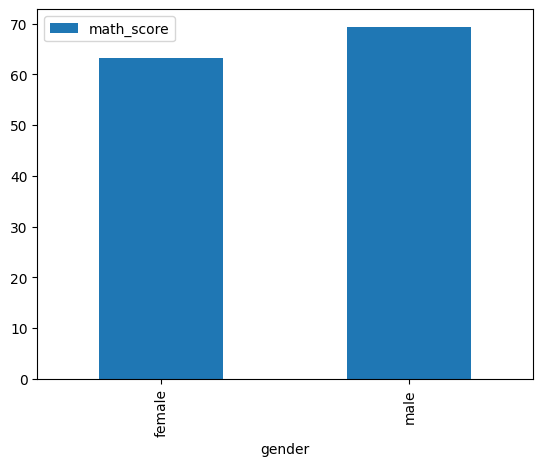

In [36]:
# pandas has its own builtin viz library
df[['gender','math_score']].groupby('gender').mean().plot(kind='bar')

In [37]:
df.groupby(['gender'])[['math_score', 'reading_score']].mean()

,math_score,reading_score
gender,,
female,63.196687,71.888199
male,69.384913,66.305609


Get the ratio of students that scored over 60 in math by gender

In [38]:
df[df['math_score']>=60].groupby(['gender'])[['math_score']].count()/len(df)

,math_score
gender,
female,0.283
male,0.382


Get the lowest writing score by class group

In [39]:
df.groupby(['class_group'])[['writing_score']].min()

,writing_score
class_group,
group A,32
group B,23
group C,23
group D,37
group E,32


Change the code above to use multiple measures (e.g. min, max, and mean) - using `agg()`

In [40]:
df.groupby(['class_group'])[['writing_score']].agg(['min','max','mean'])

writing_score                
                      min  max       mean
class_group                              
group A                32  100  66.974684
group B                23  100  65.736585
group C                23  100  64.523220
group D                37  100  72.259542
group E                32  100  70.213740

**Observation** 
- Group D has the highest mean and group C has the lowest
- All groups have some students that scored 100
- Overall average is more than 64 in writing. and all groups are above 23.
- Even though B & C have the same min & max, the averages are different.

In [41]:
df.groupby(['class_group'])[['writing_score']].describe()

writing_score                                                  \
                    count       mean        std   min    25%   50%    75%   
class_group                                                                 
group A              79.0  66.974684  16.374601  32.0  56.50  67.0  78.00   
group B             205.0  65.736585  14.866361  23.0  57.00  66.0  76.00   
group C             323.0  64.523220  15.643404  23.0  53.00  65.0  75.00   
group D             262.0  72.259542  14.665406  37.0  62.25  72.0  83.75   
group E             131.0  70.213740  15.652480  32.0  59.50  71.0  82.00   

                    
               max  
class_group         
group A      100.0  
group B      100.0  
group C      100.0  
group D      100.0  
group E      100.0

Use a custom function for aggregation. 

In [42]:
def custom_range(x):
    return x.max() - x.min()

In [43]:
df.groupby(['class_group'])[['writing_score']].agg(['min','max',custom_range, 'count'])

writing_score                        
                      min  max custom_range count
class_group                                      
group A                32  100           68    79
group B                23  100           77   205
group C                23  100           77   323
group D                37  100           63   262
group E                32  100           68   131

In [44]:
df.groupby(['class_group']).agg({'math_score':['mean',custom_range],
                                 'writing_score':['min','max']})

math_score              writing_score     
                  mean custom_range           min  max
class_group                                           
group A      65.215190           61            32  100
group B      63.170732           74            23  100
group C      63.130031           87            23  100
group D      69.267176           87            37  100
group E      74.465649           67            32  100

In [45]:
df.groupby(['class_group','gender']).agg({'math_score':['mean',custom_range],'writing_score':['min','max']})

math_score              writing_score     
                         mean custom_range           min  max
class_group gender                                           
group A     female  65.216216           61            44  100
            male    65.214286           51            32   95
group B     female  59.631579           71            28  100
            male    67.604396           63            23   96
group C     female  60.753247           81            23  100
            male    65.295858           71            26   91
group D     female  65.722222           87            37  100
            male    72.551471           65            39  100
group E     female  70.692308           67            35  100
            male    76.949367           54            32  100

In [46]:
df.groupby(['parental_level_of_education'])[['writing_score']].agg(['max','mean'])

writing_score           
                                      max       mean
parental_level_of_education                         
associate's degree                    100  70.113300
bachelor's degree                     100  74.410714
high school                            97  64.846535
master's degree                       100  75.885714
some college                          100  66.734234
some high school                       97  62.539267

Using `pivot_table`

In [47]:
df.pivot_table(index=['class_group','lunch'], columns='gender', values='reading_score', aggfunc=['mean', custom_range,'max'])

mean            custom_range         max     
gender                       female       male       female male female male
class_group lunch                                                           
group A     free/reduced  67.300000  53.375000           40   49     90   82
            standard      77.074074  69.538462           49   59    100   97
group B     free/reduced  64.175000  60.566667           59   54     88   82
            standard      70.783784  67.770492           50   62     98   96
group C     free/reduced  62.884615  58.603175           61   58     90   85
            standard      73.539216  65.839623           57   61    100   99
group D     free/reduced  69.717949  62.615385           59   55     95   91
            standard      77.597701  71.907216           56   60    100   97
group E     free/reduced  71.052632  65.150000           68   49    100   87
            standard      77.939394  76.230769           50   57    100  100

Using `crosstab()`

In [48]:
pd.crosstab(df['gender'],df['parental_level_of_education'])

parental_level_of_education,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
gender,,,,,,
female,81,58,94,42,100,108
male,122,54,108,28,122,83


**Observation**
- There are 108 male students with parental lev of edu = high school
- There are 54 male students with parental lev of edu = bachelor's degree	
- We have a close distribution between male and female for students with  parental lev of edu = bachelor's degree
- There are more female students with parents with master's degrees than males

In [49]:
pd.crosstab(df['gender'],df['parental_level_of_education'], normalize=True)

parental_level_of_education,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
gender,,,,,,
female,0.081,0.058,0.094,0.042,0.100,0.108
male,0.122,0.054,0.108,0.028,0.122,0.083


In [50]:
pd.crosstab(df['gender'],df['parental_level_of_education'], normalize='index').round(2)

parental_level_of_education,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
gender,,,,,,
female,0.17,0.12,0.19,0.09,0.21,0.22
male,0.24,0.10,0.21,0.05,0.24,0.16


`unique()` function

In [51]:
df['parental_level_of_education'].unique()

array(['high school', 'some high school', 'some college',
       "associate's degree", "bachelor's degree", "master's degree"],
      dtype=object)

`value_counts()`

In [52]:
#distribution of parental_level_of_education
df['parental_level_of_education'].value_counts()

parental_level_of_education
some college          222
associate's degree    203
high school           202
some high school      191
bachelor's degree     112
master's degree        70
Name: count, dtype: int64

<Axes: ylabel='proportion'>

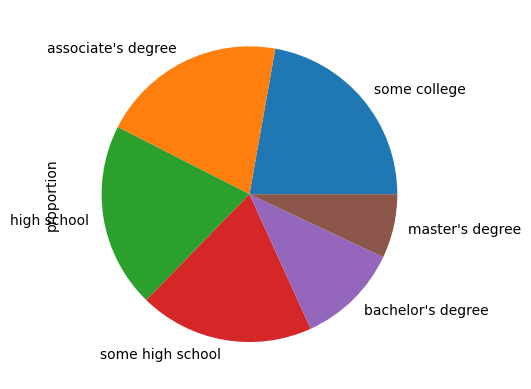

In [53]:
df['parental_level_of_education'].value_counts(normalize=True).plot(kind='pie')

In [54]:
# numerical values distribution with buckets (bins)
#example below breaks the data into 10-equal distance ranges
df['math_score'].value_counts(bins=10)

(56.5, 65.2]      209
(73.9, 82.6]      183
(65.2, 73.9]      182
(47.8, 56.5]      155
(82.6, 91.3]      114
(39.1, 47.8]       70
(91.3, 100.0]      47
(30.4, 39.1]       29
(21.7, 30.4]        9
(12.912, 21.7]      2
Name: count, dtype: int64

In [55]:
df['math_score'].value_counts(bins=10, sort=False)

(12.912, 21.7]      2
(21.7, 30.4]        9
(30.4, 39.1]       29
(39.1, 47.8]       70
(47.8, 56.5]      155
(56.5, 65.2]      209
(65.2, 73.9]      182
(73.9, 82.6]      183
(82.6, 91.3]      114
(91.3, 100.0]      47
Name: count, dtype: int64

<Axes: >

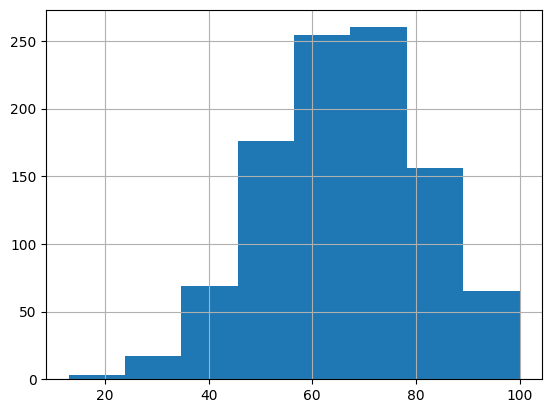

In [56]:
df['math_score'].hist(bins=8)

**Observation**
- low frequency/occurrence of students that scored between 20 and 40
- highest occurrence is between 60 and 80

Using `cut()` function

In [57]:
my_bins = [0,50,65,80,90,100]

df['average_score_bins'] = pd.cut(df['average_score'], bins=my_bins)
df.head()

,gender,class_group,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,average_score_bins
0,male,group A,high school,standard,completed,67,67,63,65.67,"(65, 80]"
1,female,group D,some high school,free/reduced,none,40,59,55,51.33,"(50, 65]"
2,male,group E,some college,free/reduced,none,59,60,50,56.33,"(50, 65]"
3,male,group B,high school,standard,none,77,78,68,74.33,"(65, 80]"
4,male,group E,associate's degree,standard,completed,78,73,68,73.00,"(65, 80]"


In [58]:
df['average_score_bins'].value_counts()

average_score_bins
(65, 80]     365
(50, 65]     304
(80, 90]     149
(0, 50]      127
(90, 100]     55
Name: count, dtype: int64

In [59]:
my_bins2 = [0,60,70,100]
my_labels = ['fail','barely passed','passed']
df['average_score_grade'] = pd.cut(df['average_score'], bins=my_bins2, labels=my_labels)
df.head()

,gender,class_group,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,average_score_bins,average_score_grade
0,male,group A,high school,standard,completed,67,67,63,65.67,"(65, 80]",barely passed
1,female,group D,some high school,free/reduced,none,40,59,55,51.33,"(50, 65]",fail
2,male,group E,some college,free/reduced,none,59,60,50,56.33,"(50, 65]",fail
3,male,group B,high school,standard,none,77,78,68,74.33,"(65, 80]",passed
4,male,group E,associate's degree,standard,completed,78,73,68,73.00,"(65, 80]",passed


<Axes: ylabel='average_score_grade'>

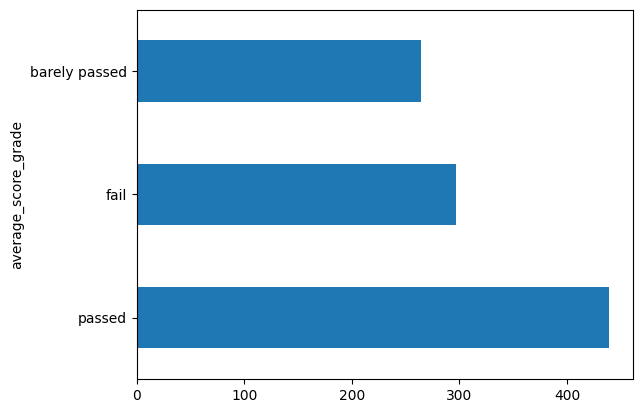

In [60]:
df['average_score_grade'].value_counts().plot(kind='barh')

<Axes: xlabel='reading_score', ylabel='writing_score'>

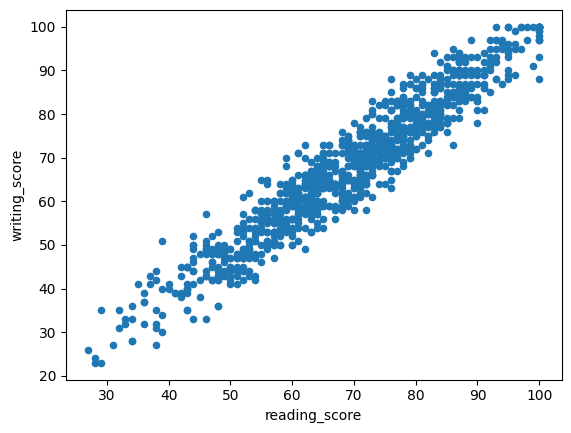

In [61]:
df.plot(kind='scatter', x='reading_score',y='writing_score')

**Observations**
- scatter plots help us understand relationship between 2 numerical columns
- we look for a diagonal band to observe association or relationship
- There's a relationship/correlation. Therefore, if reading score goes up, the writing score goes up as well.
 

In [62]:
df[['writing_score','reading_score']].corr()

,writing_score,reading_score
writing_score,1.000000,0.954274
reading_score,0.954274,1.000000
